### Prophet Baseline Forecasting --> Zaman serisi; günlük, haftalık veya yıllık gibi zamana bağlı verileri tahmin eder.

##### LangChain Google Trends zaman serisi kullanılarak Prophet modeli ile temel bir tahmin modeli oluşturulacak. Modelin performansı zaman sırasını bozmayan train/test ayrımı ile değerlendirilecek ve MAE ile RMSE hata metrikleri hesaplanacaktır.

##### Son aşamada tüm veri üzerinde model yeniden eğitilerek gelecek yaklaşık 30 günlük trend tahmini üretilecektir.

In [72]:
## Prophet zaman serisi tahmin modelini oluşturmak için kullanılır

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

from prophet import Prophet

In [73]:
df = pd.read_csv("../data/processed/langchain_global_clean.csv")
df.head()

,date,trend_score,isPartial
0,2023-08-06,24,False
1,2023-08-13,22,False
2,2023-08-20,23,False
3,2023-08-27,22,False
4,2023-09-03,22,False


In [74]:
if "isPartial" in df.columns:

    df = df[
        df["isPartial"] == False
    ].copy()

    ## Kontrol işleminden sonra artık isPartial sütununa
    ## modelleme aşamasında ihtiyacımız olmadığı için kaldırıyoruz.

    df = df.drop(
        columns=["isPartial"]
    )

In [75]:
df["date"] = pd.to_datetime(
    df["date"]
)

In [76]:
df.head()

,date,trend_score
0,2023-08-06,24
1,2023-08-13,22
2,2023-08-20,23
3,2023-08-27,22
4,2023-09-03,22


In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         158 non-null    datetime64[us]
 1   trend_score  158 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 2.6 KB


In [78]:
## Modelleme öncesinde eksik değerleri kontrol ediyoruz.
df.isna().sum()

date           0
trend_score    0
dtype: int64

In [79]:
## Zaman serisini kronolojik sıraya göre sıralıyoruz.
## Zaman serisi modellerinde gözlemlerin sırasının korunması gerekir.
# reset_index(drop=True) ---> 5>2>8>1 indexi 0>1>2>3... diye yeniden düzenler
df = (df.sort_values("date").reset_index(drop=True))

In [80]:
## Prophet modelinin bekledği sütun isimlerine dönüştürüyoruz.
## ds -> tarih
## y -> tahmin etmek istediğimiz hedef değer

prophet_df = df.rename(columns={"date": "ds","trend_score": "y"})

In [81]:
prophet_df.head()

,ds,y
0,2023-08-06,24
1,2023-08-13,22
2,2023-08-20,23
3,2023-08-27,22
4,2023-09-03,22


In [82]:
## Verimiz haftalık olduğu için son 4 gözlemi test olarak ayırıyoruz.
## 4 hafta yaklaşık 28 gün olduğu için
## projenin yaklaşık 30 günlük tahmin hedefiyle uyumludur.
##
## Zaman serisinde shuffle kullanmıyoruz.
## Geçmiş gözlemler train, sonraki gözlemler test olmalıdır.

forecast_steps = 4

train_df = prophet_df.iloc[:-forecast_steps].copy()
test_df = prophet_df.iloc[-forecast_steps:].copy()

In [83]:
## Train ve test setlerinin tarih sınırlarını kontrol ediyoruz.
## Test döneminin train döneminden sonra geldiğini doğruluyoru

print("Train  başlangıç:", train_df["ds"].min())
print("Train bitiş:",train_df["ds"].max())

print("Test başlangıç:",test_df["ds"].min())
print("Test bitiş:",test_df["ds"].max())

Train  başlangıç: 2023-08-06 00:00:00
Train bitiş: 2026-07-12 00:00:00
Test başlangıç: 2026-07-19 00:00:00
Test bitiş: 2026-08-09 00:00:00


In [84]:
## Baseline Prophet modeli

prophet_model = Prophet()

In [85]:
## Prophet modelini yalnızca geçmiş dönemi temsil eden
## train veri seti üzerinde eğitiyoruz.
##
## Test verisini model burada kesinlikle görmüyor.

prophet_model.fit(train_df)

11:54:21 - cmdstanpy - INFO - Chain [1] start processing
11:54:21 - cmdstanpy - INFO - Chain [1] done processing


In [86]:
##Test dönemindeki tarihleri modele veriyoruz.
## Model bu tarihler için trend skorlarını tahin edecek.

test_feature = test_df[["ds"]].copy()

In [87]:
## Test dönemine ait tahminleri üretiyoruz.
test_forecast = prophet_model.predict(test_feature)

In [88]:
# yhat --> Modelin ana tahmini
# yhat_lower --> Tahmin aralığının alt sınırı
# yhat_upper --> Tahmin aralığının üst sınırı.


test_forecast[["ds","yhat","yhat_lower","yhat_upper"]].head()

,ds,yhat,yhat_lower,yhat_upper
0,2026-07-19,79.465483,68.943632,90.260581
1,2026-07-26,89.402367,78.902277,101.213447
2,2026-08-02,98.362881,86.662529,108.888628
3,2026-08-09,102.228301,91.070445,113.519815


In [89]:
test_df["y"]

154    46
155    44
156    28
157    24
Name: y, dtype: int64

In [90]:
test_forecast["yhat"]

0     79.465483
1     89.402367
2     98.362881
3    102.228301
Name: yhat, dtype: float64

In [91]:
## Test dönemindeki gerçek değerler ile
## Prophet tahminleri aynı Dataframe içeriisnde birleştirilecek

results_df = pd.DataFrame({"date": test_df["ds"].values, 
                           "actual": test_df["y"].values, 
                           "predicted": test_forecast["yhat"].values
})

In [92]:
results_df.head(10)

,date,actual,predicted
0,2026-07-19,46,79.465483
1,2026-07-26,44,89.402367
2,2026-08-02,28,98.362881
3,2026-08-09,24,102.228301


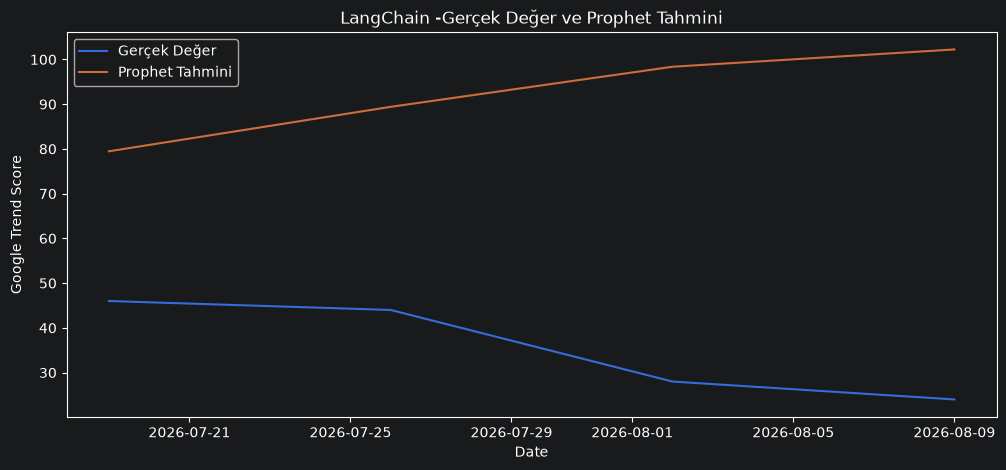

In [93]:
## Test dönemindeki gerçek trend değerleri ile
## Prophet modelinin tahminlerini karşılaştırıyoruz.

plt.figure(figsize=(12, 5))

plt.plot(results_df["date"],
        results_df["actual"],
        label="Gerçek Değer")

plt.plot(results_df["date"],
        results_df["predicted"],
        label="Prophet Tahmini")

plt.title("LangChain -Gerçek Değer ve Prophet Tahmini")
plt.xlabel("Date")
plt.ylabel("Google Trend Score")

plt.legend()
plt.show()

##### Prophet geçmişte öğrendiği uzun dönemli yükseliş eğiliminin devam edeceğini varsaymış, fakat test dönemindeki ani yapısal düşüşü tahmin edememiş. 

##### Prophet modeli, test döneminin sonundaki sert trend değişimini yakalayamadı..

##### ARIMA/SARIMAX modeli ile karşılaştırılacak

In [94]:
results_df

,date,actual,predicted
0,2026-07-19,46,79.465483
1,2026-07-26,44,89.402367
2,2026-08-02,28,98.362881
3,2026-08-09,24,102.228301


In [95]:
!pip install scikit-learn

In [96]:
## Prophet modelini hata perfonmasını değerlendirmek için 
## MAE ve RMSE metriklerini kullanıyoruz.

from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [97]:
## Gerçek test değerleri ile Prohet tahminleri arasındaki
## ortalama mutlak hatayı hesaplıyoruz.

mae = mean_absolute_error(
    results_df["actual"],
    results_df["predicted"]

)

print("MAE:", mae)

MAE: 56.864757966003395


In [98]:
## Büyük tahmin hatalarını daha fazla cezalandıran
## Root Mean Squared Error değerini hesaplıyoruz.

rmse = root_mean_squared_error(
    results_df["actual"],
    results_df["predicted"]
)

print("RMSE:", rmse)

RMSE: 59.69069353309914


In [99]:
print(f"Prophet MAE : {mae:.2f}")
print(f"Prophet RMSE: {rmse:.2f}")

Prophet MAE : 56.86
Prophet RMSE: 59.69


##### Modelin tahminleri test döneminde gerçek Google Trends skorlarından ortalama yaklaşık 16.55 puan sapmıştır. RMSE değerinin MAE’den daha yüksek olması, test döneminde bazı büyük tahmin hatalarının bulunduğunu gösteriyor.

In [100]:
## Her tahmin noktasındaki hatayı ayrı ayrı incelemek için
## gerçek değer ile tahmin arasındaki farkı hesaplıyoruz.

results_df["error"] = (results_df["actual"]- results_df["predicted"])

In [101]:
## Hatanın yönünden bağımsız olarak büyüklüğünü görmek için
## mutlak hata sütunu oluşturuyoruz.

results_df["absolute_error"] = (results_df["error"].abs())

In [102]:
results_df.head(10)

,date,actual,predicted,error,absolute_error
0,2026-07-19,46,79.465483,-33.465483,33.465483
1,2026-07-26,44,89.402367,-45.402367,45.402367
2,2026-08-02,28,98.362881,-70.362881,70.362881
3,2026-08-09,24,102.228301,-78.228301,78.228301


In [103]:
## Prophet modelinin en büyük hatayı yaptığı
## 5 test gözlemini buluyoruz.

results_df.nlargest(5,"absolute_error")

,date,actual,predicted,error,absolute_error
3,2026-08-09,24,102.228301,-78.228301,78.228301
2,2026-08-02,28,98.362881,-70.362881,70.362881
1,2026-07-26,44,89.402367,-45.402367,45.402367
0,2026-07-19,46,79.465483,-33.465483,33.465483


In [104]:
## Prophet modelinin zaman serisine uygun cross-validation
## ve perfonmans değerlendirme araçlarını kullanıyoruz.

from prophet.diagnostics import (cross_validation, performance_metrics)

In [105]:
## Cross-validation için tüm mevcut geçmiş veri üzerinde
## ayrı bir Prophet modeli oluşturuyoruz.
##
## Cross-validation fonksiyonu kendi içinde farklı cutoff noktaları
## oluşturarak her cutoff için modeli geçmiş verilerle yeniden eğitir.


cv_model = Prophet()
cv_model.fit(prophet_df)

11:54:26 - cmdstanpy - INFO - Chain [1] start processing
11:54:26 - cmdstanpy - INFO - Chain [1] done processing


In [106]:
## Time-Series Cross-Validation uyguluyoruz.
##
## initial:
## İlk modelin eğitiminde kullanılacak minimum geçmiş veri miktarı.
##
## period:
## Yeni cutoff noktaları arasındaki mesafe.
##
## horizon:
## Her cutoff noktasından sonra ne kadar ileriye tahmin yapılacağı

cv_results = cross_validation(cv_model, 
                              initial="730 days",
                              period ="90 days",
                              horizon="90 days"
                             )

  0%|          | 0/4 [00:00<?, ?it/s]

11:54:27 - cmdstanpy - INFO - Chain [1] start processing
11:54:27 - cmdstanpy - INFO - Chain [1] done processing
11:54:27 - cmdstanpy - INFO - Chain [1] start processing
11:54:27 - cmdstanpy - INFO - Chain [1] done processing
11:54:27 - cmdstanpy - INFO - Chain [1] start processing
11:54:27 - cmdstanpy - INFO - Chain [1] done processing
11:54:27 - cmdstanpy - INFO - Chain [1] start processing
11:54:27 - cmdstanpy - INFO - Chain [1] done processing


In [107]:
## initial="730 days" yaklaşık 2 yıllık ilk eğitim dönemi demek.

## 2023 ---------------- 2025
##     yaklaşık 2 yıl

In [108]:
cv_results.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2025-08-17,41.986156,34.726549,49.947348,83,2025-08-14
1,2025-08-24,35.716620,27.562989,43.233189,64,2025-08-14
2,2025-08-31,33.619571,25.389204,41.216519,63,2025-08-14
3,2025-09-07,35.221472,28.120498,43.085073,61,2025-08-14
4,2025-09-14,37.066801,28.861973,45.159486,59,2025-08-14


In [109]:
## Cross-validation sonuçlarından hata metriklerini hesaplıyoruz.

cv_metrics = performance_metrics(cv_results)

cv_metrics.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,10 days,661.235155,25.714493,21.209198,0.264590,0.278721,0.331855,0.2
1,11 days,327.846577,18.106534,13.785979,0.176441,0.079237,0.210997,0.4
2,12 days,341.880448,18.490009,14.612910,0.185719,0.125629,0.221306,0.6
3,13 days,197.689914,14.060225,10.533830,0.146590,0.083074,0.173870,0.8
4,17 days,369.123012,19.212574,15.918219,0.234076,0.125629,0.289634,0.6


In [110]:
cv_metrics[["horizon", "mae", "rmse"]].head(10)

,horizon,mae,rmse
0,10 days,21.209198,25.714493
1,11 days,13.785979,18.106534
2,12 days,14.612910,18.490009
3,13 days,10.533830,14.060225
4,17 days,15.918219,19.212574
5,18 days,12.020385,14.986685
6,19 days,14.137578,16.233233
7,20 days,15.575644,17.441599
8,24 days,19.236012,20.638210
9,25 days,18.011056,19.012071


In [111]:
## Farklı forecast horizonlarında elde edilen
## MAE ve RMSE değerlerinin ortalamasını hesaplıyoruz.

cv_mae = cv_metrics["mae"].mean()
cv_rmse = cv_metrics["rmse"].mean()

print(f"Cross-Validation Ortalama MAE : {cv_mae:.2f}")
print(f"Cross-Validation Ortalama RMSE: {cv_rmse:.2f}")

Cross-Validation Ortalama MAE : 22.84
Cross-Validation Ortalama RMSE: 26.65


##### Prophet bazı dönemlerde ortalama olarak kayda değer hata yapmakta ve özellikle belirli trend kırılmalarında büyük tahmin hataları üretebilmektedir.

### 30 günlük tahmin algoritmasını

In [112]:
## Prophet'in yaklaşık 30 günlük tahmin performansını
## farklı geçmiş dönemlerde değerlendirmek için
## 30 günlük Time-Series Cross-Validation uyguluyoruz.

cv_results_30 = cross_validation(
    cv_model,
    initial="730 days",
    period="90 days",
    horizon="30 days"
)

  0%|          | 0/4 [00:00<?, ?it/s]

11:54:30 - cmdstanpy - INFO - Chain [1] start processing
11:54:30 - cmdstanpy - INFO - Chain [1] done processing
11:54:30 - cmdstanpy - INFO - Chain [1] start processing
11:54:30 - cmdstanpy - INFO - Chain [1] done processing
11:54:30 - cmdstanpy - INFO - Chain [1] start processing
11:54:30 - cmdstanpy - INFO - Chain [1] done processing
11:54:30 - cmdstanpy - INFO - Chain [1] start processing
11:54:30 - cmdstanpy - INFO - Chain [1] done processing


In [113]:
## 30 günlük cross-validation sonuçlarından
## genel MAE ve RMSE skorlarını hesaplıyoruz.

cv_metrics_30 = performance_metrics(cv_results_30,rolling_window=1)

cv_metrics_30[["horizon", "mae", "rmse"]]

,horizon,mae,rmse
0,30 days,21.176068,31.762746


In [114]:
## Modelin değerlendirme aşaması tamamlandıktan sonra,
## gerçek geleceği tahmin etmek için tüm mevcut geçmiş veriyi kullanıyoruz.
##
## Böylece model, elimizde bulunan maksimum geçmiş bilgiden yararlanır.

final_prophet_model = Prophet()

In [115]:
## Final Prophet modelini tüm geçmiş LangChain verisi üzerinde eğitiyoruz.
##
## Burada test seti ayırmıyoruz çünkü artık model performansını ölçmüyoruz;
## gelecekte henüz gözlemlemediğimiz dönemi tahmin ediyoruz.

final_prophet_model.fit(prophet_df)

11:54:31 - cmdstanpy - INFO - Chain [1] start processing
11:54:31 - cmdstanpy - INFO - Chain [1] done processing


In [116]:
## Veri setimiz haftalık olduğu için yaklaşık 30 günlük geleceği
## 4 haftalık tahmin ediyoruz.
##
## freq="W-SUN":
## Gelecek gözlemlerin de mevcut veri gibi pazar günlerine
## karşılık gelmesini sağlıyor.

future_dates = final_prophet_model.make_future_dataframe(
    periods=4,
    freq="W-SUN"
)

In [117]:
future_dates.tail(10)

,ds
152,2026-07-05
153,2026-07-12
154,2026-07-19
155,2026-07-26
156,2026-08-02
157,2026-08-09
158,2026-08-16
159,2026-08-23
160,2026-08-30
161,2026-09-06


In [118]:
## Tüm geçmiş ve oluşturulan gelecek tarihler için
## Prophet tahminlerini üretiyoruz.

future_forecast = final_prophet_model.predict(
    future_dates
)

In [119]:
future_forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].tail(10)

,ds,yhat,yhat_lower,yhat_upper
152,2026-07-05,68.991127,54.113826,84.331191
153,2026-07-12,64.740688,50.258352,80.566205
154,2026-07-19,62.732171,48.296197,78.099269
155,2026-07-26,64.670854,50.019229,79.908263
156,2026-08-02,70.612569,55.392609,86.356548
157,2026-08-09,78.351972,63.059646,92.832149
158,2026-08-16,84.498850,68.907723,99.001925
159,2026-08-23,86.769183,71.154399,101.900235
160,2026-08-30,85.592723,70.490884,100.381213
161,2026-09-06,83.499957,68.301340,98.345224


In [120]:
## Veri setindeki son gerçek tarihi belirliyoruz.

last_date = prophet_df["ds"].max()

print("Son gerçek gözlem tarihi:",last_date)

Son gerçek gözlem tarihi: 2026-08-09 00:00:00


In [121]:
## Son gerçek tarihten sonraki tahminleri seçiyoruz.
## Böylece yalnızca geleceğe ait forecast değerlerini elde ediyoruz.

future_only = future_forecast[future_forecast["ds"] > last_date][[
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]].copy()

In [122]:
future_only

,ds,yhat,yhat_lower,yhat_upper
158,2026-08-16,84.498850,68.907723,99.001925
159,2026-08-23,86.769183,71.154399,101.900235
160,2026-08-30,85.592723,70.490884,100.381213
161,2026-09-06,83.499957,68.301340,98.345224


In [123]:
## Tahmin sonuçlarını raporlama sırasında daha okunabilir
## hale getirmek için iki ondalık basamağa yuvarlıyoruz.

future_only[
    [
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
] = future_only[
    [
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].round(2)

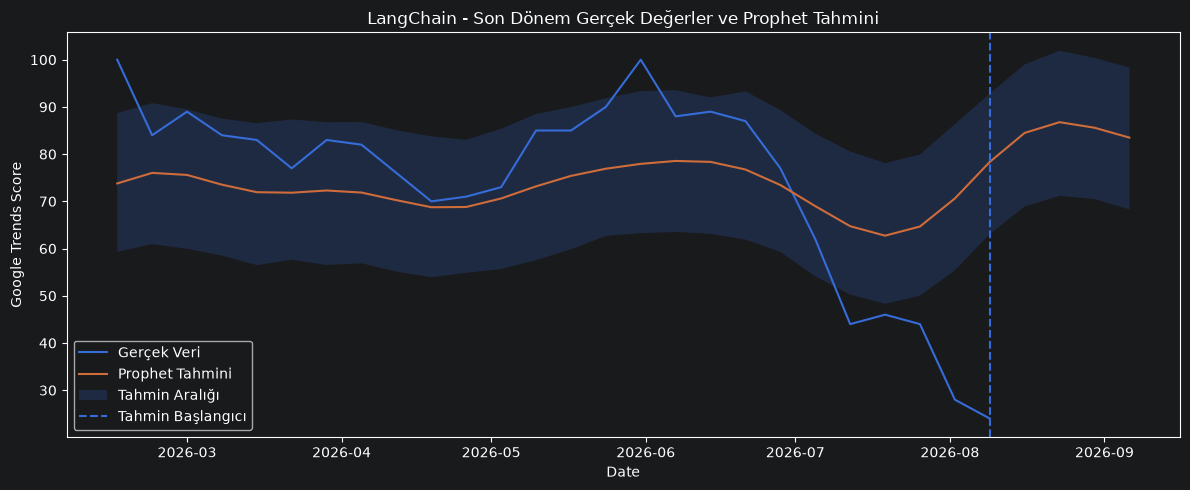

In [124]:
## Son dönemde modelin gerçek veriye ne kadar uyduğunu
## ve gelecek tahminlerini daha açık görebilmek için
## yalnızca son birkaç aylık dönemi gösteriyoruz.

recent_start = prophet_df["ds"].max() - pd.Timedelta(days=180)

recent_actual = prophet_df[
    prophet_df["ds"] >= recent_start
].copy()

recent_forecast = future_forecast[
    future_forecast["ds"] >= recent_start
].copy()


plt.figure(figsize=(12, 5))


## Gerçek gözlemler

plt.plot(
    recent_actual["ds"],
    recent_actual["y"],
    label="Gerçek Veri"
)


## Prophet'in geçmiş + gelecek tahmin çizgisi

plt.plot(
    recent_forecast["ds"],
    recent_forecast["yhat"],
    label="Prophet Tahmini"
)


## Tahmin belirsizlik aralığı

plt.fill_between(
    recent_forecast["ds"],
    recent_forecast["yhat_lower"],
    recent_forecast["yhat_upper"],
    alpha=0.2,
    label="Tahmin Aralığı"
)


## Gerçek verinin bittiği noktayı gösteriyoruz.

plt.axvline(
    x=last_date,
    linestyle="--",
    label="Tahmin Başlangıcı"
)


plt.title(
    "LangChain - Son Dönem Gerçek Değerler ve Prophet Tahmini"
)

plt.xlabel("Date")
plt.ylabel("Google Trends Score")

plt.legend()
plt.tight_layout()
plt.show()

In [125]:
future_only

,ds,yhat,yhat_lower,yhat_upper
158,2026-08-16,84.50,68.91,99.00
159,2026-08-23,86.77,71.15,101.90
160,2026-08-30,85.59,70.49,100.38
161,2026-09-06,83.50,68.30,98.35
